In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    "../data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "text"]
)

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4457
Test size: 1115


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_df=0.95,
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(4457, 1347)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, y_pred, pos_label="spam"))
print("F1:", f1_score(y_test, y_pred, pos_label="spam"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9739910313901345
Precision: 1.0
Recall: 0.8053691275167785
F1: 0.8921933085501859

Confusion Matrix:
[[966   0]
 [ 29 120]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [5]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, y_pred, pos_label="spam"))
print("F1:", f1_score(y_test, y_pred, pos_label="spam"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.97847533632287
Precision: 0.9194630872483222
Recall: 0.9194630872483222
F1: 0.9194630872483222

Confusion Matrix:
[[954  12]
 [ 12 137]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.92      0.92      0.92       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



Тест разных порогов вероятности

In [7]:
y_proba = model.predict_proba(X_test_tfidf)[:, 1]  # вероятность класса "spam"


In [10]:
import numpy as np

for t in [0.3, 0.5, 0.7, 0.9]:
    y_pred_t = np.where(y_proba >= t, "spam", "ham")
    
    precision = precision_score(y_test, y_pred_t, pos_label="spam")
    recall = recall_score(y_test, y_pred_t, pos_label="spam")
    
    print(f"Threshold {t}: Precision={precision:.3f}, Recall={recall:.3f}")

Threshold 0.3: Precision=0.724, Recall=0.953
Threshold 0.5: Precision=0.919, Recall=0.919
Threshold 0.7: Precision=0.992, Recall=0.859
Threshold 0.9: Precision=1.000, Recall=0.631


receiver operating characteristic

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

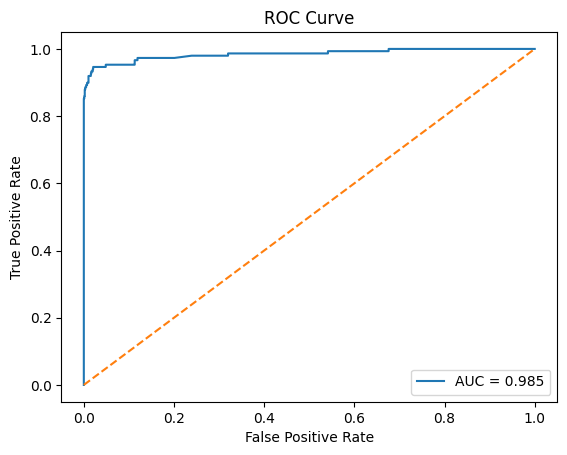

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label="spam")
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()